In [2]:
import pandas as pd
import numpy as np

import seaborn as sns #Para Graficos
sns.set_style('darkgrid')
import matplotlib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier #mezcla de varios algoritmos
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold #En cuanto puedo partir los datos

import string
import warnings
warnings.filterwarnings('ignore')
SEED = 42

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/titanic_train.csv')
#df.head()
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
#Cabin → ELIMINAR debido a que le falta mucha data
df = df.drop(columns=['Cabin'])
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [6]:
# Age → Rellenar con mediana
# ¿Por qué mediana y no promedio?
# Porque la edad puede tener outliers y la mediana es más robusta.

df['Age'].fillna(df['Age'].median(), inplace=True)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
# Embarked → Rellenar con moda
# Son solo 2 valores.
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


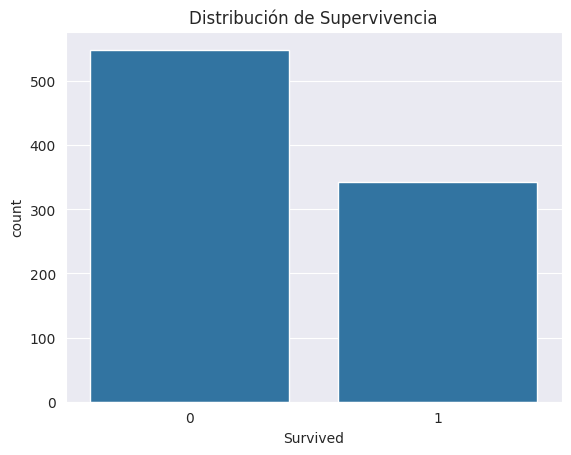

In [8]:
# Distribución de supervivencia

sns.countplot(x='Survived', data=df)
plt.title("Distribución de Supervivencia")
plt.show()

## Análisis de Supervivencia General

Se observa que la mayoría de pasajeros no sobrevivió al desastre.
Aproximadamente el 62% de los pasajeros falleció, mientras que solo el 38% logró sobrevivir.
Esto indica que la probabilidad general de supervivencia fue baja.

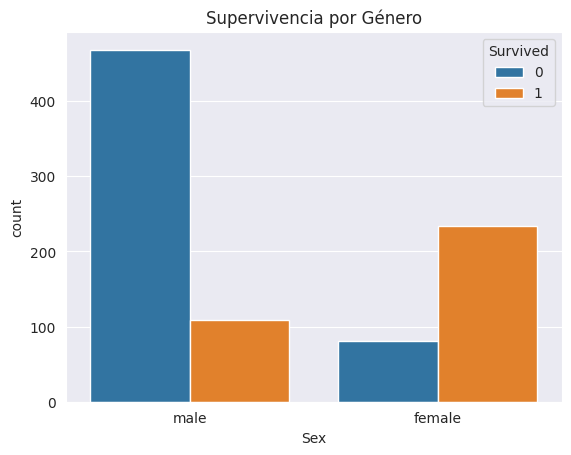

In [11]:
#Supervivencia por género
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Supervivencia por Género")
plt.show()

In [12]:
# Ahora vamos a verlo (con porcentajes)
df.groupby('Sex')['Survived'].mean() * 100

,Survived
Sex,
female,74.203822
male,18.890815


## Supervivencia por Género

Se observa una diferencia significativa en la tasa de supervivencia según el género.

Aproximadamente el 74% de las mujeres sobrevivió, mientras que solo alrededor del 19% de los hombres logró sobrevivir.

Esto sugiere que el género fue un factor determinante en la probabilidad de supervivencia.

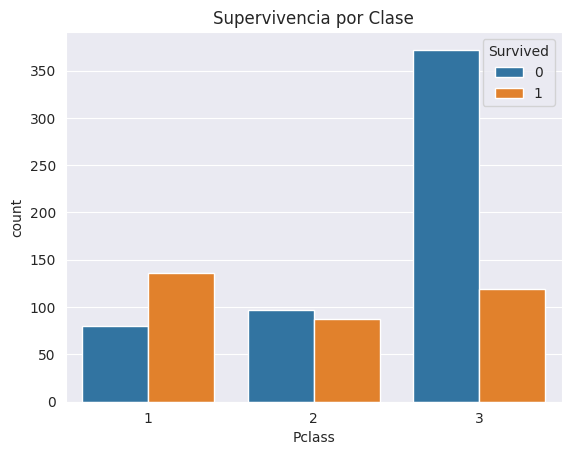

In [13]:
# Vamoa a ver Supervivencia por clase (Pclass)
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Supervivencia por Clase")
plt.show()

In [14]:
df.groupby('Pclass')['Survived'].mean() * 100

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


## Supervivencia por Clase

Se observa una relación clara entre la clase del pasajero y la probabilidad de supervivencia.

Los pasajeros de primera clase tuvieron la mayor tasa de supervivencia (aprox. 63%),
mientras que los de tercera clase tuvieron la menor (aprox. 24%).

Esto sugiere que el nivel socioeconómico influyó en las posibilidades de sobrevivir.

In [15]:
# Análisi cruzado de genero y clase
pd.crosstab(df['Pclass'], df['Sex'], df['Survived'], aggfunc='mean') * 100

Sex,female,male
Pclass,,
1,96.808511,36.885246
2,92.105263,15.740741
3,50.000000,13.544669
